In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output

## 1. Q-learning in the wild (3 pts)

Here we use the qlearning agent on taxi env from openai gym.
You will need to insert a few agent functions here.

In [2]:
import random,math
import numpy as np
from collections import defaultdict

class QLearningAgent():
  """
    Q-Learning Agent

    Instance variables you have access to
      - self.epsilon (exploration prob)
      - self.alpha (learning rate)
      - self.discount (discount rate aka gamma)

    Functions you should use
      - self.getLegalActions(state)
        which returns legal actions for a state
      - self.getQval(state,action)
        which returns Q(state,action)
      - self.setQval(state,action,val)
        which sets Q(state,action) := val

    !!!Important!!!
    NOTE: please avoid using self._qvals directly to make code cleaner
  """
  def __init__(self,alpha,epsilon,discount,getLegalActions):
    "We initialize agent and Q-vals here."
    self.getLegalActions= getLegalActions
    self._qvals = defaultdict(lambda:defaultdict(lambda:0))
    self.alpha = alpha
    self.epsilon = epsilon
    self.discount = discount

  def getQval(self, state, action):
    #print(state)
    #print(action)
    if not (state in self._qvals) or not (action in self._qvals[state]):
        return 0.0
    return self._qvals[state][action]

  def setQval(self,state,action,val):
    """
      Sets the Qval for [state,action] to the given val
    """
    self._qvals[state][action] = val

#---------------------#start of your code#---------------------#

  def getval(self, state):
    """
      Returns max_action Q(state,action)
      where the max is over legal actions.
    """

    possibleActions = self.getLegalActions(state)
    #If there are no legal actions, return 0.0
    if len(possibleActions) == 0:
        return 0.0

    return max(self.getQval(state, i) for i in possibleActions)

  def getPolicy(self, state):
    """
      Compute the best action to take in a state.

    """
    possibleActions = self.getLegalActions(state) 

    #If there are no legal actions, return None
    if len(possibleActions) == 0:
      return None
    q = max(self.getQval(state, i) for i in possibleActions)
    for i in possibleActions:
      if(self.getQval(state, i) == q):
        return i

  def getAction(self, state):
    """
      Compute the action to take in the current state, including exploration.

      With probability self.epsilon, we should take a random action.
      otherwise - the best policy action (self.getPolicy).

      HINT: You might want to use util.flipCoin(prob)
      HINT: To pick randomly from a list, use random.choice(list)

    """

    # Pick Action
    possibleActions = self.getLegalActions(state)
    #If there are no legal actions, return None
    if len(possibleActions) == 0:
      return None
    #choose action with epsilon exploration strategy:
    if random.random() <= self.epsilon:
        res = random.choice(possibleActions)
    else:
        res = self.getPolicy(state)

    return res

  def update(self, state, action, nextState, reward):
    """
      You should do your Q-val update here

      NOTE: You should never call this function,
      it will be called on your behalf


    """
    #agent parameters
    gamma = self.discount
    learning_rate = self.alpha

    "*** YOUR CODE HERE ***"
    myq = self.getQval(state, action)
    nx = self.getval(nextState)
    to = reward + gamma * nx
    new_q = (1 - learning_rate)*myq + learning_rate *to

    self.setQval(state, action, new_q)

In [3]:
import gym
env = gym.make("Taxi-v3")
n_actions = env.action_space.n

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
c:\Users\forxh\AppData\Local\Programs\Python\Python313\Lib\site-packages\gym\core.py:329: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\forxh\AppData\Local\Programs\Python\Python313\Lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behav

In [4]:
def play_and_train(env,agent,t_max=10**4):
    """This function should
    - run a full game, actions given by agent.getAction(s)
    - train agent using agent.update(...) whenever possible
    - return total reward"""
    total_reward = 0.0
    s = env.reset()

    for t in range(t_max):
        a = agent.getAction(s)

        next_s,r,done,_ = env.step(a)

        agent.update(s, a, next_s, r)

        s = next_s
        total_reward +=r
        if (done):break

    return total_reward

In [5]:
agent = QLearningAgent(alpha=0.5,epsilon=0.4,discount=0.95,
                       getLegalActions = lambda s: range(n_actions))

Достигните положительной награды, постройте график

In [6]:
from IPython.display import clear_output


0.052


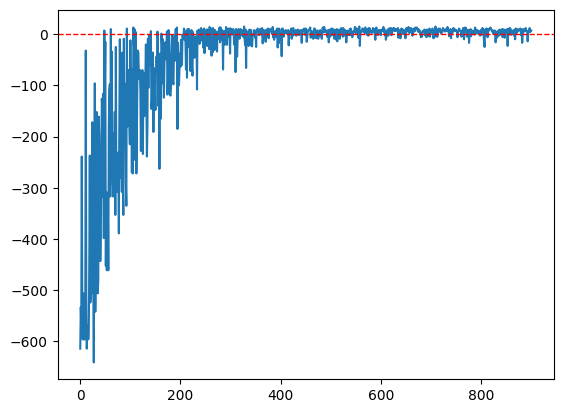

In [7]:
from IPython.display import clear_output
rewards = []
for i in range(1000):
    rewards.append(play_and_train(env,agent))
    agent.epsilon *= 0.99
    agent.epsilon = max(agent.epsilon, 0.052)
    if i % 100 ==0:
        clear_output(True)
        print(agent.epsilon)
        plt.plot(rewards)
        plt.axhline(0, color='red', linestyle='--', linewidth=1, label='y=0')
        plt.show()


## 3. Continuous state space (2 pt)

Чтобы использовать табличный q-learning на continuous состояниях, надо как-то их обрабатывать и бинаризовать. Придумайте способ разбивки на дискретные состояния.

In [8]:
env = gym.make("CartPole-v0")
# env = env.unwrapped

n_actions = env.action_space.n
env.reset()
# print("first state:%s"%(env.reset()))


c:\Users\forxh\AppData\Local\Programs\Python\Python313\Lib\site-packages\gym\envs\registration.py:592: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(


array([ 0.03411692, -0.01588156, -0.0146056 , -0.02083414], dtype=float32)

### Play a few games

Постройте распределения различных частей состояния игры. Сыграйте несколько игр и запишите все состояния.

In [9]:
sts = []

for ep in range(52):
    state= env.reset()
    ok = False
    while not ok:
        sts.append(state)
        f = env.action_space.sample()  # random action
        # print(env.step(f))
        s, r, done, _,  = env.step(f)
        ok = (done)

sts_ar = np.array(sts)
print("sts:", sts_ar.shape)


sts: (1113, 4)


## Binarize environment

In [10]:
from gym.core import ObservationWrapper
class Binarizer(ObservationWrapper):

    def __init__(self, env, n_bins=6):
        super().__init__(env)
        self.n_bins = n_bins

        self.obs_low = np.array([-4.8, -5, -0.418, -5])
        self.obs_high = np.array([4.8, 5, 0.418, 5])

    def to_bin(self, val, l, r):
        val = min(max(val, l), r)
        hmt = (val - l) / (r - l) * (self.n_bins - 1)
        return int(hmt)

    def observation(self, state):
        binned_state = (
            self.to_bin(state[0], self.obs_low[0], self.obs_high[0]),
            self.to_bin(state[1], self.obs_low[1], self.obs_high[1]),
            self.to_bin(state[2], self.obs_low[2], self.obs_high[2]),
            self.to_bin(state[3], self.obs_low[3], self.obs_high[3])
        )
        return binned_state

In [11]:
env = Binarizer(gym.make("CartPole-v0"))

## Learn

In [12]:
agent = QLearningAgent(alpha=0.7,epsilon=0.7,discount=0.95,
                       getLegalActions = lambda s: range(n_actions))

3.021987318746049e-05
12.58


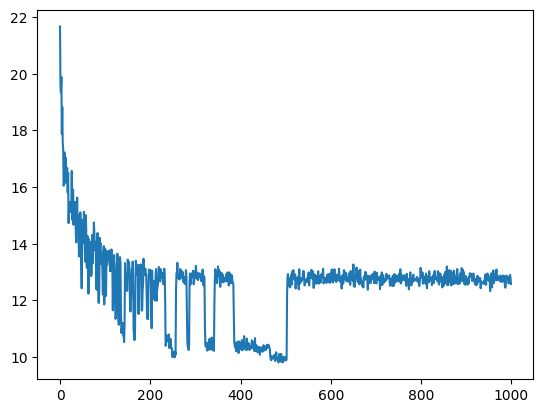

In [13]:
rewards = []
rewBuf = []
ma = -1000000000000
for i in range(1000):
    for i in range(100):
        rewards.append(play_and_train(env,agent))
    agent.epsilon *= 0.99
    rewBuf.append(np.mean(rewards[-100:]))
    clear_output(True)
    print(agent.epsilon)
    print(rewBuf[-1])
    plt.plot(rewBuf)
    if(rewBuf[-1] > 195):
        print("Win!")
        break
    plt.show()


## 4. Experience replay (5 pts)

In [14]:
import random
class ReplayBuffer(object):
    def __init__(self, size):
        """Create Replay buffer.
        Parameters
        ----------
        size: int
            Max number of transitions to store in the buffer. When the buffer
            overflows the old memories are dropped.
        """
        self._storage = []
        self._maxsize = size
        self._replaceId = 0


    def __len__(self):
        return len(self._storage)

    def add(self, obs_t, action, reward, obs_tp1, done):
        '''
        Make sure, _storage will not exceed _maxsize.
        '''
        data = (obs_t, action, reward, obs_tp1, done)
        if len(self._storage) < self._maxsize:
             self._storage.append(data) 
            #
        else:
            self._storage[self._replaceId] = data
            self._replaceId = (self._replaceId + 1) % self._maxsize
            #

    def sample(self, batch_size):
        """Sample a batch of experiences.
        Parameters
        ----------
        batch_size: int
            How many transitions to sample.
        Returns
        -------
        obs_batch: np.array
            batch of observations
        act_batch: np.array
            batch of actions executed given obs_batch
        rew_batch: np.array
            rewards received as results of executing act_batch
        next_obs_batch: np.array
            next set of observations seen after executing act_batch
        done_mask: np.array
            done_mask[i] = 1 if executing act_batch[i] resulted in
            the end of an ep and 0 otherwise.
        """

        prs = random.sample(range(len(self._storage)), batch_size)
    
        sts, act, r, nx, cd = zip(*(self._storage[i] for i in prs))
        
        sts = np.array(sts)
        act = np.array(act)
        r = np.array(r)
        nx = np.array(nx)
        cd = np.array(cd, dtype=np.uint8)  
        

        return sts, act, r, nx, cd


Some tests to make sure your buffer works right

In [15]:
import numpy as np
replay = ReplayBuffer(2)
obj1 = tuple(range(5))
obj2 = tuple(range(5, 10))
replay.add(*obj1)
assert replay.sample(1)==obj1, "If there's just one object in buffer, it must be retrieved by buf.sample(1)"
replay.add(*obj2)
assert len(replay._storage)==2, "Please make sure __len__ methods works as intended."
replay.add(*obj2)
assert len(replay._storage)==2, "When buffer is at max capacity, replace objects instead of adding new ones."
replay.add(*obj1)
replay.add(*obj1)
print ("Success!")

Success!


Now let's use this buffer to improve training:

In [16]:
import gym
env = Binarizer(gym.make('CartPole-v0'))
n_actions = env.action_space.n

In [17]:
agent = QLearningAgent(alpha=0.7,epsilon=0.7,discount=0.95,
                       getLegalActions = lambda s: range(n_actions))
replay = ReplayBuffer(10000)

In [18]:
def play_and_train(env, agent, t_max=10**4, batch_size=10):
    """This function should
    - run a full game, actions given by agent.getAction(s)
    - train agent using agent.update(...) whenever possible
    - return total reward"""
    total_reward = 0.0
    s = env.reset()

    for t in range(t_max):
        action = agent.getAction(s)
        next_s, r, done,_ = env.step(action)

        #заполните реплей
        #опционально - моежте также как в варианте без реплея обучатьcя по cоcтояниям которые
        replay.add(s, action, r, next_s, done)

        if len(replay) >= batch_size:
            batch = replay.sample(batch_size)
            # print(len(batch)) 
            sts, acts, rewards_batch, next_sts, dones = replay.sample(batch_size)
            for state_b, action_b, reward_b, next_state_b, done_b in zip(sts, acts, rewards_batch, next_sts, dones):
                    agent.update(tuple(state_b), action_b,tuple(next_state_b), reward_b)
        s = next_s
        total_reward +=r
        if done:break

    #learn from replay

    return total_reward




Train with experience replay

0.2562226388912603
12.28


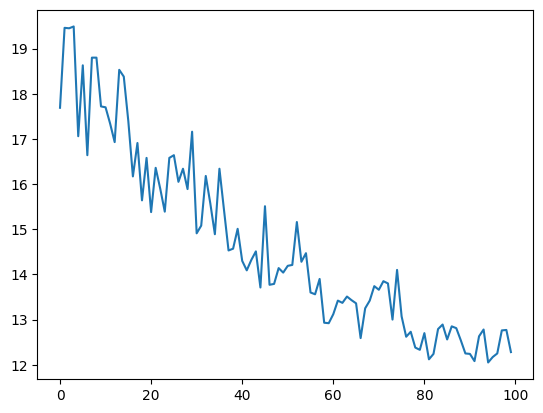

In [19]:
rewards = []
rewBuf = []
ma = -1000000000000
for i in range(100  ):
    for i in range(100):
        rewards.append(play_and_train(env,agent, batch_size=1000))
    agent.epsilon *= 0.99
    rewBuf.append(np.mean(rewards[-100:]))
    clear_output(True)
    print(agent.epsilon)
    print(rewBuf[-1])
    plt.plot(rewBuf)
    if(rewBuf[-1] > 195):
        print("Win!")
        break
    plt.show()
